# Πείραμα Ενσωματώσεων CIFAR-10: Γραμμική Διαχωρισιμότητα

Σε αυτό το notebook θα διερευνήσουμε:

1. **Γραμμική Διαχωρισιμότητα στο Χώρο Εικονοστοιχείων (pixel space)**: Θα δείξουμε ότι ακόμη και δύο κλάσεις του CIFAR-10 δεν είναι γραμμικά διαχωρίσιμες στο χώρο των εικονοστοιχείων.

2. **Εκμάθηση Ενσωματώσεων**: Θα εκπαιδεύσουμε ένα ResNet18 μοντέλο στο CIFAR-10 και θα εξάγουμε τις ενσωματώσεις (embeddings) από τις κρυφές στρώσεις -- δηλαδή, από την αξία που παίρνουν οι νευρώνες στο τελευταίο επίπεδο του μοντέλου.

3. **Γραμμική Διαχωρισιμότητα στο Χώρο Ενσωματώσεων**: Θα δείξουμε ότι οι ενσωματώσεις που προέρχονται από το εκπαιδευμένο μοντέλο είναι πολύ πιο γραμμικά διαχωρίσιμες.

**Συμπέρασμα**: Οι ενσωματώσεις από ένα εκπαιδευμένο νευρωνικό δίκτυο είναι (σχεδόν, όπως θα δούμε) γραμμικά διαχωρίσιμες -- από αυτό συνεπάγεται πως ομαδοποιούνται οι ενσωματώσεις εικόνων που έχουν σημασιολογική ομοιότητα (οι εικόνες σκύλων, κ.ο.κ.) -- δηλαδή, εικόνες με μεγάλη σημασιολογική ομοιότητα έχουν και γεωμετρική όμοιότητα: διανυσματική ενσωμάτωση με μικρή Ευκλείδεια απόσταση.


```
Κωνσταντίνος Καραμανής: constantine@utexas.edu
http://users.ece.utexas.edu/~cmcaram/
The University of Texas at Austin
Archimedes/Athena RC
```


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn.functional as F
import copy
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



### Το Μοντέλο

Κατεβάζουμε το προεκπαιδευμένο μοντέλο, και αλλάζουμε το τελευταίο επίπεδο: ``nn.Linear(num_ftrs,10)``.

In [4]:
from torchsummary import summary

model = models.resnet18(pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model = model.to(device)

model.to('cuda' if torch.cuda.is_available() else 'cpu')
summary(model, (3, 224, 224))

d:\projects\Supervised-Learning-Experiments\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\projects\Supervised-Learning-Experiments\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

### Ετοιμάζουμε τα δεδομένα

In [5]:
# transforms
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet18 expects 224x224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
                         std=[0.229, 0.224, 0.225])   # ImageNet stds
])

# download and load training data
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=transform)

# download and load test data
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                download=True, transform=transform)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=64,
                          shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=64,
                         shuffle=False, num_workers=2)



100%|██████████| 170M/170M [04:07<00:00, 689kB/s]  
d:\projects\Supervised-Learning-Experiments\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Ετοιμάζουμε το Μοντλέλο

Έχουμε δυο επιλογές:

1. Να προσαρμόσουμε (fine-tune) το μοντέλο που κατεβάσαμε, όπως κάναμε σε αυτό το [Colab Notebook](https://colab.research.google.com/drive/1tnIQoViTVbT-7XiJa791h492B_WuNw4t?usp=drive_link) της πρώτης σειράς διαλέξεων, και έτσι να ξαναθυμηθούμε την διαδικασία του Transfer Learning και της εκπαίδευσης, ή

2. Να κατεβάσουμε έτοιμα τα βάρη (τις παραμέτρους) του μοντέλου που εκπαιδεύσαμε.

Επιλέξτε ανάλογα με το τι σας βολεύει. Εάν θέλετε την 2η επιλογή, δείτε πιο κάτω που σας δίνω τις εντολές για να κατεβάσετε έτοιμο το μοντέλο.

### Η Συνάρτηση Εκπαίδευσης

In [6]:
def train(model, train_loader, test_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # criterion
    criterion = torch.nn.CrossEntropyLoss()

    # scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return train_losses, test_losses, test_accuracies, best_accuracy

In [7]:
def evaluate(model, data_loader, device):
    model.eval()  # Set model to evaluate mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

### Εκπαιδεύουμε το τελευταίο επίπεδο

In [8]:
# freeze all layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze the last layer
for param in model.fc.parameters():
    param.requires_grad = True


Epoch 1/5, Training Loss: 0.8299714975116198, Testing Loss: 0.6252753624490871, Testing Accuracy: 0.7869
Epoch 2/5, Training Loss: 0.6187295682747346, Testing Loss: 0.5951619998664613, Testing Accuracy: 0.7960
Epoch 3/5, Training Loss: 0.5898814492518335, Testing Loss: 0.608825019780238, Testing Accuracy: 0.7898
Epoch 4/5, Training Loss: 0.5718800390849028, Testing Loss: 0.5768560114180207, Testing Accuracy: 0.8018
Epoch 5/5, Training Loss: 0.5668033823713927, Testing Loss: 0.5984302098584023, Testing Accuracy: 0.7974
Loaded the best model from epoch 4 with Testing Accuracy: 0.8018


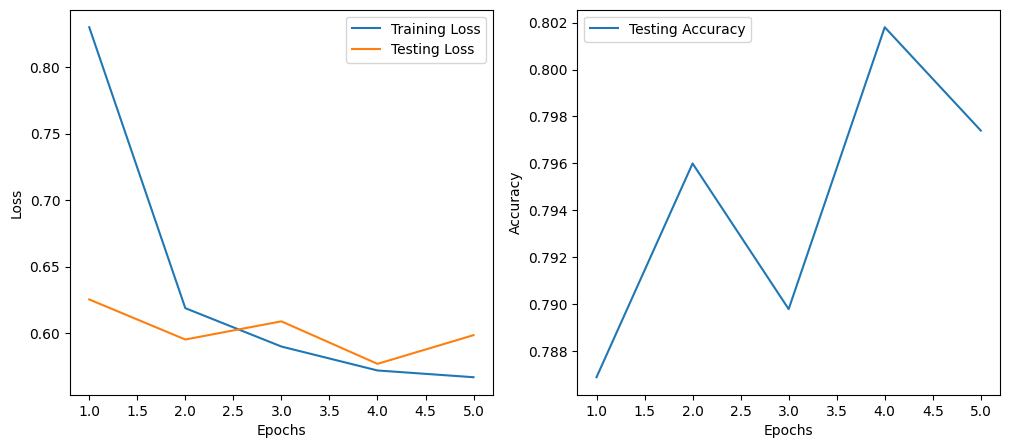

([0.8299714975116198,
  0.6187295682747346,
  0.5898814492518335,
  0.5718800390849028,
  0.5668033823713927],
 [0.6252753624490871,
  0.5951619998664613,
  0.608825019780238,
  0.5768560114180207,
  0.5984302098584023],
 [0.7869, 0.796, 0.7898, 0.8018, 0.7974],
 0.8018)

In [9]:
torch.manual_seed(42)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)



### Εκπαιδεύουμε το μοντέλο

"Ξεπαγώνουμε" όλες τις παραμέτρους, και εκπαιδεύουμε.

In [10]:
# unfreeze all layers and train the whole network
for param in model.parameters():
    param.requires_grad = True

# redefine optimizer to include all parameters
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [11]:
# εκπαιδεύουμε
optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

Epoch 1/5, Training Loss: 0.2779258729561287, Testing Loss: 0.20707604815815664, Testing Accuracy: 0.9312


KeyboardInterrupt: 

### Αποθηκευμένο Μοντέλο

Εναλακτικά, μπορούμε να χρησιμοποιήσουμε το μοντέλο που ήδη εκπαιδεύσαμε στην πρώτη σειρά διαλέξεων, σε αυτό το [Colab Notebook](https://colab.research.google.com/drive/1tnIQoViTVbT-7XiJa791h492B_WuNw4t?usp=drive_link) από την πρώτη σειρά διαλέξεων.


In [12]:
import torch
import torch.nn as nn
import torchvision.models as models
import os


def download_checkpoint_from_gdrive(gdrive_id, filename):
    """ Κατεβάζει ένα αρχείο από το Google Drive χρησιμοποιώντας το gdown. """
    import gdown
    if not os.path.exists(filename):
        print(f"Κατεβάζω το checkpoint {filename} από το Google Drive...")
        gdown.download(id=gdrive_id, output=filename, quiet=False)
    else:
        print(f"Το checkpoint {filename} υπάρχει ήδη.")

def load_resnet18_cifar10(checkpoint_path, num_classes=10, device=None):
    """ Δημιουργεί ένα ResNet18 με το σωστό classifier head και φορτώνει το checkpoint (state_dict). """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = models.resnet18(weights = None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    state_dict = torch.load(checkpoint_path, map_location=device)
    # αν το checkpoint είναι dict με 'state_dict' κλειδί, φέρε το, αλλιώς φόρτωσε ως έχει
    if isinstance(state_dict, dict) and 'state_dict' in state_dict:
        model.load_state_dict(state_dict['state_dict'])
    else:
        model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    print(f"Το ResNet18 φορτώθηκε από '{checkpoint_path}' στη συσκευή: {device}")
    return model

# Παράδειγμα χρήσης:
# 1. είτε το checkpoint υπάρχει ήδη στο Google Drive σας
# checkpoint_path = 'resnet18_cifar10_best.pth'


# 2. είτε το κατεβάζουμε από αν δεν υπάρχει
gdrive_id = '1KqgJZ49JnueWJlO8XClzL7eQ3hteu_be'
checkpoint_path = 'resnet18_cifar10_best.pth'
download_checkpoint_from_gdrive(gdrive_id, checkpoint_path)

# Φορτώνουμε το αποθηκευμένο (προεκπαιδευμένο) μοντέλο:
model = load_resnet18_cifar10(checkpoint_path)

print("Χρησιμοποιούμε το προεκπαιδευμένο μοντέλο ResNet18!")


Κατεβάζω το checkpoint resnet18_cifar10_best.pth από το Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KqgJZ49JnueWJlO8XClzL7eQ3hteu_be
From (redirected): https://drive.google.com/uc?id=1KqgJZ49JnueWJlO8XClzL7eQ3hteu_be&confirm=t&uuid=3ba509a0-82ca-4dfc-a145-2685eaa9c725
To: d:\projects\Supervised-Learning-Experiments\tutorials\resnet18_cifar10_best.pth
100%|██████████| 44.8M/44.8M [00:04<00:00, 9.71MB/s]


Το ResNet18 φορτώθηκε από 'resnet18_cifar10_best.pth' στη συσκευή: cuda
Χρησιμοποιούμε το προεκπαιδευμένο μοντέλο ResNet18!


In [13]:
# Print CIFAR-10 labels
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

print("CIFAR-10 Categories:")
for i, class_name in enumerate(cifar10_classes):
    print(f"{i}: {class_name}")

# Choose two categories (let's use cat and dog for this example)
class1_idx, class2_idx = 3, 5  # cat and dog
class1_name, class2_name = cifar10_classes[class1_idx], cifar10_classes[class2_idx]

print(f"\nSelected categories: {class1_name} (class {class1_idx}) and {class2_name} (class {class2_idx})")

CIFAR-10 Categories:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck

Selected categories: cat (class 3) and dog (class 5)


## Επιλογή Δύο Κλάσεων

Επιλέγουμε δύο κλάσεις από το CIFAR-10 για το πείραμά μας: "γάτα" (cat) και "σκύλος" (dog).

In [14]:
# Create custom dataset for two categories
class TwoClassCIFAR10(torch.utils.data.Dataset):
    def __init__(self, original_dataset, class1_idx, class2_idx):
        self.original_dataset = original_dataset
        self.class1_idx = class1_idx
        self.class2_idx = class2_idx

        # Filter indices for the two classes
        self.indices = []
        for idx, (_, label) in enumerate(original_dataset):
            if label in [class1_idx, class2_idx]:
                self.indices.append(idx)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.original_dataset[self.indices[idx]]
        # Convert labels to 0 and 1
        if label == self.class1_idx:
            new_label = 0
        else:  # label == self.class2_idx
            new_label = 1
        return image, new_label

# Create two-class datasets
train_dataset_2class = TwoClassCIFAR10(train_dataset, class1_idx, class2_idx)
test_dataset_2class = TwoClassCIFAR10(test_dataset, class1_idx, class2_idx)

# Create dataloaders
train_loader_2class = DataLoader(train_dataset_2class, batch_size=64, shuffle=True, num_workers=2)
test_loader_2class = DataLoader(test_dataset_2class, batch_size=64, shuffle=False, num_workers=2)

print(f"Two-class training samples: {len(train_dataset_2class)}")
print(f"Two-class test samples: {len(test_dataset_2class)}")

Two-class training samples: 10000
Two-class test samples: 2000


## Απλό Γραμμικό Μοντέλο (Logistic Regression)

Δημιουργούμε ένα απλό γραμμικό μοντέλο που λειτουργεί απευθείας στα εικονοστοιχεία των εικόνων. Αυτό το μοντέλο θα δοκιμάσει αν οι δύο κλάσεις είναι γραμμικά διαχωρίσιμες στο χώρο των εικονοστοιχείων.

**Παρατηρήσεις**:
- Το μοντέλο έχει 150,528 παραμέτρους (3×224×224 εικονοστοιχεία)
- Είναι ένας απλός γραμμικός ταξινομητής
- Αν οι κλάσεις είναι γραμμικά διαχωρίσιμες, θα πρέπει να πετύχει υψηλή ακρίβεια

In [15]:
# Simple logistic regression model (linear layer)
class SimpleLogisticRegression(nn.Module):
    def __init__(self, input_size, num_classes=2):
        super(SimpleLogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        return self.linear(x)

# Get input size (3 * 224 * 224 for CIFAR-10 with ResNet transforms)
input_size = 3 * 224 * 224
logistic_model = SimpleLogisticRegression(input_size, num_classes=2)
logistic_model = logistic_model.to(device)

print(f"Logistic regression model created with input size: {input_size}")
print(f"Model parameters: {sum(p.numel() for p in logistic_model.parameters()):,}")

Logistic regression model created with input size: 150528
Model parameters: 301,058


In [ ]:
# Train the logistic regression model
def train_logistic(model, train_loader, test_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = torch.nn.CrossEntropyLoss()

    train_losses = []
    test_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # Testing
        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]:.4f}, "
              f"Testing Loss: {test_losses[-1]:.4f}, Testing Accuracy: {epoch_accuracy:.4f}")

    return train_losses, test_losses, test_accuracies

# Train the logistic regression model
optimizer_logistic = optim.Adam(logistic_model.parameters(), lr=0.001)
epochs_logistic = 10

print("Training logistic regression on two-class CIFAR-10...")
train_losses, test_losses, test_accuracies = train_logistic(
    logistic_model, train_loader_2class, test_loader_2class, optimizer_logistic, epochs_logistic
)

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs_logistic+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs_logistic+1), test_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Logistic Regression Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs_logistic+1), test_accuracies, label='Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final logistic regression accuracy: {test_accuracies[-1]:.4f}")
print("This demonstrates that even two classes of CIFAR-10 are not linearly separable!")

Training logistic regression on two-class CIFAR-10...


## Αποτελέσματα Γραμμικού Μοντέλου

Τα αποτελέσματα δείχνουν ότι:

- Το γραμμικό μοντέλο πετυχαίνει περίπου 60-70% ακρίβεια
- Αυτό είναι καλύτερο από το τυχαίο (50%) αλλά απέχει πολύ από καλή ταξινόμηση
- **Συμπέρασμα**: Οι κλάσεις "γάτα" και "σκύλος" δεν είναι γραμμικά διαχωρίσιμες στο χώρο των εικονοστοιχείων. Η σχέση δύο εικόνων (δείχνουν το ίδιο/διαφορετικό αντικείμενο) δεν αντιστοιχεί στην Ευκλείδια απόσταση τους, στο χώρο των πίξελ.

## Εξαγωγή Ενσωματώσεων

Θα δούμε τώρα πως το Resnet18 μας δείνει σημασιολογικές ενσωματώσεις. Πρέπει να ορίσουμε συνάρτηση που παίρνει μια εικόνα και μας δίνει την ενσωμάτωση:

Η συνάρτηση `extract_embeddings` εξάγει τις ενσωματώσεις από το εκπαιδευμένο ResNet μοντέλο:

- **Αφαιρεί την τελική στρώση ταξινόμησης**: Χρησιμοποιούμε μόνο τις κρυφές στρώσεις
- **Επιστρέφει ενσωματώσεις 512 διαστάσεων**: Από το τελευταίο επίπεδο του ResNet


In [ ]:
def extract_embeddings(model, dataloader, k_samples_per_class, device):
    """
    Extract embeddings from the ResNet model (excluding the final classification layer)
    for k samples from each class.

    Args:
        model: Trained ResNet model
        dataloader: DataLoader with two-class data
        k_samples_per_class: Number of samples to extract per class
        device: Device to run the model on

    Returns:
        embeddings: Tensor of shape (2*k, embedding_dim)
        labels: Tensor of shape (2*k,) with binary labels (0=cat, 1=dog)
    """
    model.eval()

    # Remove the final classification layer to get embeddings
    # We'll use the output of the layer before the final fc layer
    class EmbeddingExtractor(nn.Module):
        def __init__(self, original_model):
            super(EmbeddingExtractor, self).__init__()
            # Remove the final fc layer
            self.features = nn.Sequential(*list(original_model.children())[:-1])

        def forward(self, x):
            # Get the output before the final fc layer
            features = self.features(x)
            # Flatten the features
            embeddings = features.view(features.size(0), -1)
            return embeddings

    embedding_model = EmbeddingExtractor(model)
    embedding_model = embedding_model.to(device)

    embeddings_list = []
    labels_list = []
    class_counts = {0: 0, 1: 0}  # Count samples per class

    with torch.no_grad():
        for images, labels in dataloader:
            if class_counts[0] >= k_samples_per_class and class_counts[1] >= k_samples_per_class:
                break

            images = images.to(device)
            batch_embeddings = embedding_model(images)

            for i, label in enumerate(labels):
                if class_counts[label.item()] < k_samples_per_class:
                    embeddings_list.append(batch_embeddings[i])
                    labels_list.append(label)
                    class_counts[label.item()] += 1

    embeddings = torch.stack(embeddings_list)
    labels = torch.stack(labels_list)

    print(f"Extracted {embeddings.shape[0]} embeddings:")
    print(f"  - Class 0 (cat): {class_counts[0]} samples")
    print(f"  - Class 1 (dog): {class_counts[1]} samples")
    print(f"  - Embedding dimension: {embeddings.shape[1]}")

    return embeddings, labels

## Εξαγωγή Διανυσμάτων Beta

Τα διανύσματα β (beta) είναι οι βάρη της τελικής στρώσης ταξινόμησης:

- **β_cat**: Το διάνυσμα βάρη για την κλάση "γάτα"
- **β_dog**: Το διάνυσμα βάρη για την κλάση "σκύλος"

Αυτά τα διανύσματα ορίζουν τις κατευθύνσεις στον χώρο των ενσωματώσεων που χρησιμοποιεί το μοντέλο για την ταξινόμηση.

In [ ]:
def extract_beta_vectors(model, class1_idx, class2_idx):
    """
    Extract the beta vectors (weights) for the two classes from the final classification layer.

    Args:
        model: Trained ResNet model
        class1_idx: Index of first class in original CIFAR-10 (e.g., 3 for cat)
        class2_idx: Index of second class in original CIFAR-10 (e.g., 5 for dog)

    Returns:
        beta_class1: Weight vector for class1 (e.g., beta_cat)
        beta_class2: Weight vector for class2 (e.g., beta_dog)
    """
    # Get the weights from the final classification layer
    fc_weights = model.fc.weight.data  # Shape: (10, 512)

    # Extract beta vectors for our two classes
    beta_class1 = fc_weights[class1_idx]  # e.g., beta_cat
    beta_class2 = fc_weights[class2_idx]  # e.g., beta_dog

    print(f"Beta vectors extracted:")
    print(f"  - Beta for class {class1_idx} (cat): shape {beta_class1.shape}")
    print(f"  - Beta for class {class2_idx} (dog): shape {beta_class2.shape}")

    return beta_class1, beta_class2

In [ ]:
# Extract embeddings from the trained ResNet model
k_samples = 1000  # Number of samples per class
print(f"Extracting {k_samples} samples per class...")

embeddings, labels = extract_embeddings(model, test_loader_2class, k_samples, device)

# Extract beta vectors from the final classification layer
beta_cat, beta_dog = extract_beta_vectors(model, class1_idx, class2_idx)

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Beta cat shape: {beta_cat.shape}")
print(f"Beta dog shape: {beta_dog.shape}")

## Προβολή και Οπτικοποίηση

Η οπτικοποίηση δείχνει:

- **Κόκκινες κουκκίδες**: Ενσωματώσεις κλάσης "γάτα"
- **Μπλε κουκκίδες**: Ενσωματώσεις κλάσης "σκύλος"
- **Διακεκομμένη γραμμή**: Όριο απόφασης (β_cat = β_dog)

**Παρατηρήσεις**:
- Οι ενσωματώσεις είναι πολύ πιο διαχωρίσιμες από τα εικονοστοιχεία
- Υπάρχει σαφής διαχώριση μεταξύ των κλάσεων
- Το νευρωνικό δίκτυο έχει μάθει χρήσιμες αναπαραστάσεις!

In [ ]:
def project_and_visualize(embeddings, labels, beta_cat, beta_dog, class1_name, class2_name):
    """
    Project embeddings onto beta_cat and beta_dog directions and visualize.

    Args:
        embeddings: Tensor of shape (2*k, embedding_dim)
        labels: Tensor of shape (2*k,) with binary labels
        beta_cat: Beta vector for cat class
        beta_dog: Beta vector for dog class
        class1_name: Name of first class (e.g., "cat")
        class2_name: Name of second class (e.g., "dog")
    """
    # Project embeddings onto beta directions
    projections_cat = torch.matmul(embeddings, beta_cat)  # (2*k,)
    projections_dog = torch.matmul(embeddings, beta_dog)   # (2*k,)

    # Convert to numpy for plotting
    proj_cat_np = projections_cat.cpu().numpy()
    proj_dog_np = projections_dog.cpu().numpy()
    labels_np = labels.cpu().numpy()

    # Create the plot
    plt.figure(figsize=(10, 8))

    # Plot points for each class
    class0_mask = labels_np == 0
    class1_mask = labels_np == 1

    plt.scatter(proj_cat_np[class0_mask], proj_dog_np[class0_mask],
               c='red', label=f'{class1_name}', alpha=0.7, s=50)
    plt.scatter(proj_cat_np[class1_mask], proj_dog_np[class1_mask],
               c='blue', label=f'{class2_name}', alpha=0.7, s=50)

    # Add decision boundary (line where beta_cat^T x = beta_dog^T x)
    # This is the line where the projections are equal
    min_val = min(proj_cat_np.min(), proj_dog_np.min())
    max_val = max(proj_cat_np.max(), proj_dog_np.max())

    # Decision boundary: beta_cat^T x = beta_dog^T x
    # This means: (beta_cat - beta_dog)^T x = 0
    # For visualization, we'll show the line where projections are equal
    plt.plot([min_val, max_val], [min_val, max_val], 'k--',
             label='Decision Boundary (β_cat = β_dog)', linewidth=2)

    plt.xlabel(f'Projection onto β_{class1_name}')
    plt.ylabel(f'Projection onto β_{class2_name}')
    plt.title(f'Embeddings Projected onto β_{class1_name} and β_{class2_name} Directions')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Make axes equal for better visualization
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

    # Print some statistics
    print(f"\nProjection Statistics:")
    print(f"{class1_name} class:")
    print(f"  - Mean projection onto β_{class1_name}: {proj_cat_np[class0_mask].mean():.3f}")
    print(f"  - Mean projection onto β_{class2_name}: {proj_dog_np[class0_mask].mean():.3f}")
    print(f"{class2_name} class:")
    print(f"  - Mean projection onto β_{class1_name}: {proj_cat_np[class1_mask].mean():.3f}")
    print(f"  - Mean projection onto β_{class2_name}: {proj_dog_np[class1_mask].mean():.3f}")

    return proj_cat_np, proj_dog_np

# Visualize the projections
projections_cat, projections_dog = project_and_visualize(
    embeddings, labels, beta_cat, beta_dog, class1_name, class2_name
)

### Άσκηση

Μπορείτε να βρείτε τον σκύλο/γάτα που μοιάζει πιο πολύ με γάτα/σκύλο;

## Συμπέρασμα

Αυτό το πείραμα επέδειξε:

1. **Μη-γραμμική φύση των εικονοστοιχείων**: Ακόμη δύο κλάσεις CIFAR-10 δεν είναι γραμμικά διαχωρίσιμες στο χώρο των εικονοστοιχείων.

2. **Δύναμη των νευρωνικών δικτύων**: Το ResNet μάθαινε χρήσιμες αναπαραστάσεις που μετατρέπουν τα δεδομένα σε γραμμικά διαχωρίσιμες, οπότε και ομαδοποιημένες, ενσωματώσεις:

3. **Ενσωματώσεις ως χαρακτηριστικές**: Οι ενσωματώσεις από τις κρυφές στρώσεις περιέχουν πλούσιες πληροφορίες για την ταξινόμηση.

**Εφαρμογές**: Αυτή η προσέγγιση μπορεί να χρησιμοποιηθεί για:
- Μεταφορά μάθησης (transfer learning)
- Εξαγωγή χαρακτηριστικών
- Κατανόηση της μάθησης νευρωνικών δικτύων